## Introduction

Bike sharing systems represent a modern, automated approach to traditional bike rentals, where the entire process — from membership and rental to return — is handled without manual intervention. Users can rent a bike from one location and return it at a different one, making these systems highly convenient for short-distance urban travel. With over 500 bike-sharing programs operating worldwide today, these systems play an increasingly important role in addressing traffic congestion, reducing environmental impact, and promoting public health.

This project uses the **Capital Bikeshare** dataset from Washington D.C., USA, covering rental activity across the years **2011 and 2012**. The data is available at two levels of granularity:
- `day.csv` — daily aggregated rental counts (731 records)
- `hour.csv` — hourly rental counts (17,379 records)

Both datasets include not just rental counts, but also corresponding **weather and seasonal information** — such as temperature, humidity, windspeed, and weather conditions — along with calendar-related details like season, holiday status, and working day indicators.

Understanding what drives bike rental demand has real business value. Bike-sharing operators need to predict demand accurately to ensure the right number of bikes are available at the right time and location, avoiding both shortages and idle inventory. Weather and seasonal patterns, in particular, can significantly influence how many people choose to rent a bike on a given day.

The objective of this project is twofold:
1. To perform a detailed exploratory analysis of the dataset, uncovering patterns and relationships between rental demand and environmental/seasonal factors.
2. To build a predictive model that estimates the daily bike rental count (`cnt`) based on these environmental and seasonal settings, and to compare multiple modeling approaches to identify the best one for production use.

The following sections walk through data understanding, exploratory analysis, preprocessing, model building, model comparison, and the challenges encountered throughout this process.

## Problem Statement

Bike sharing systems have become an important part of urban transportation, and rental demand is highly influenced by environmental and seasonal factors such as weather conditions, temperature, humidity, and time-related variables like season, holiday, and working day status.

This project is based on the Capital Bikeshare dataset (Washington D.C., USA), which contains daily (`day.csv`) and hourly (`hour.csv`) records of bike rentals along with corresponding weather and seasonal information for the years 2011 and 2012.

**The project consists of the following tasks:**

1. **Data Analysis Report** — Perform a complete exploratory data analysis of the given dataset to uncover patterns, trends, and relationships between rental demand and environmental/seasonal factors.

2. **Prediction Model** — Build a model to predict the daily bike rental count (`cnt`) based on environmental and seasonal settings.

3. **Model Comparison Report** — Train and evaluate multiple models on the dataset, compare their performance, and recommend the best model for production use.

4. **Challenges Report** — Document the challenges faced during data preparation and modeling, along with the techniques used to address them and the reasoning behind those choices.

## Import

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Automated Tuning
from sklearn.model_selection import GridSearchCV
import joblib

## Load Data

In [35]:
df_day = pd.read_csv('../Data/day.csv')
df_hour = pd.read_csv('../Data/hour.csv')
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [36]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [37]:
df_day.shape

(731, 16)

In [38]:
df_day.size

11696

## Observation :
day.csv dataset have `731 'rows' and 16 'columns'`

## Data Understanding :


In [39]:
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [40]:
df_day.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [41]:
df_day.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [42]:
df_day.duplicated().sum()

np.int64(0)

In [43]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [44]:
df_day.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [45]:
df_day.nunique()

instant       731
dteday        731
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          499
atemp         690
hum           595
windspeed     650
casual        606
registered    679
cnt           696
dtype: int64

## Dataset Overview
- Dataset contains 731 rows and 16 columns
- By dtype: 1 object column (dteday), 15 numerical columns
- However, 7 of these numerical columns (season, yr, mnth, holiday, weekday, 
  workingday, weathersit) are actually categorical in nature — they represent 
  labels/categories, not continuous quantities
- True continuous numerical columns: temp, atemp, hum, windspeed, casual, 
  registered, cnt
- No missing values and no duplicate rows found

## EDA ---> Exploritory Data Analysis

In [46]:
df_day.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

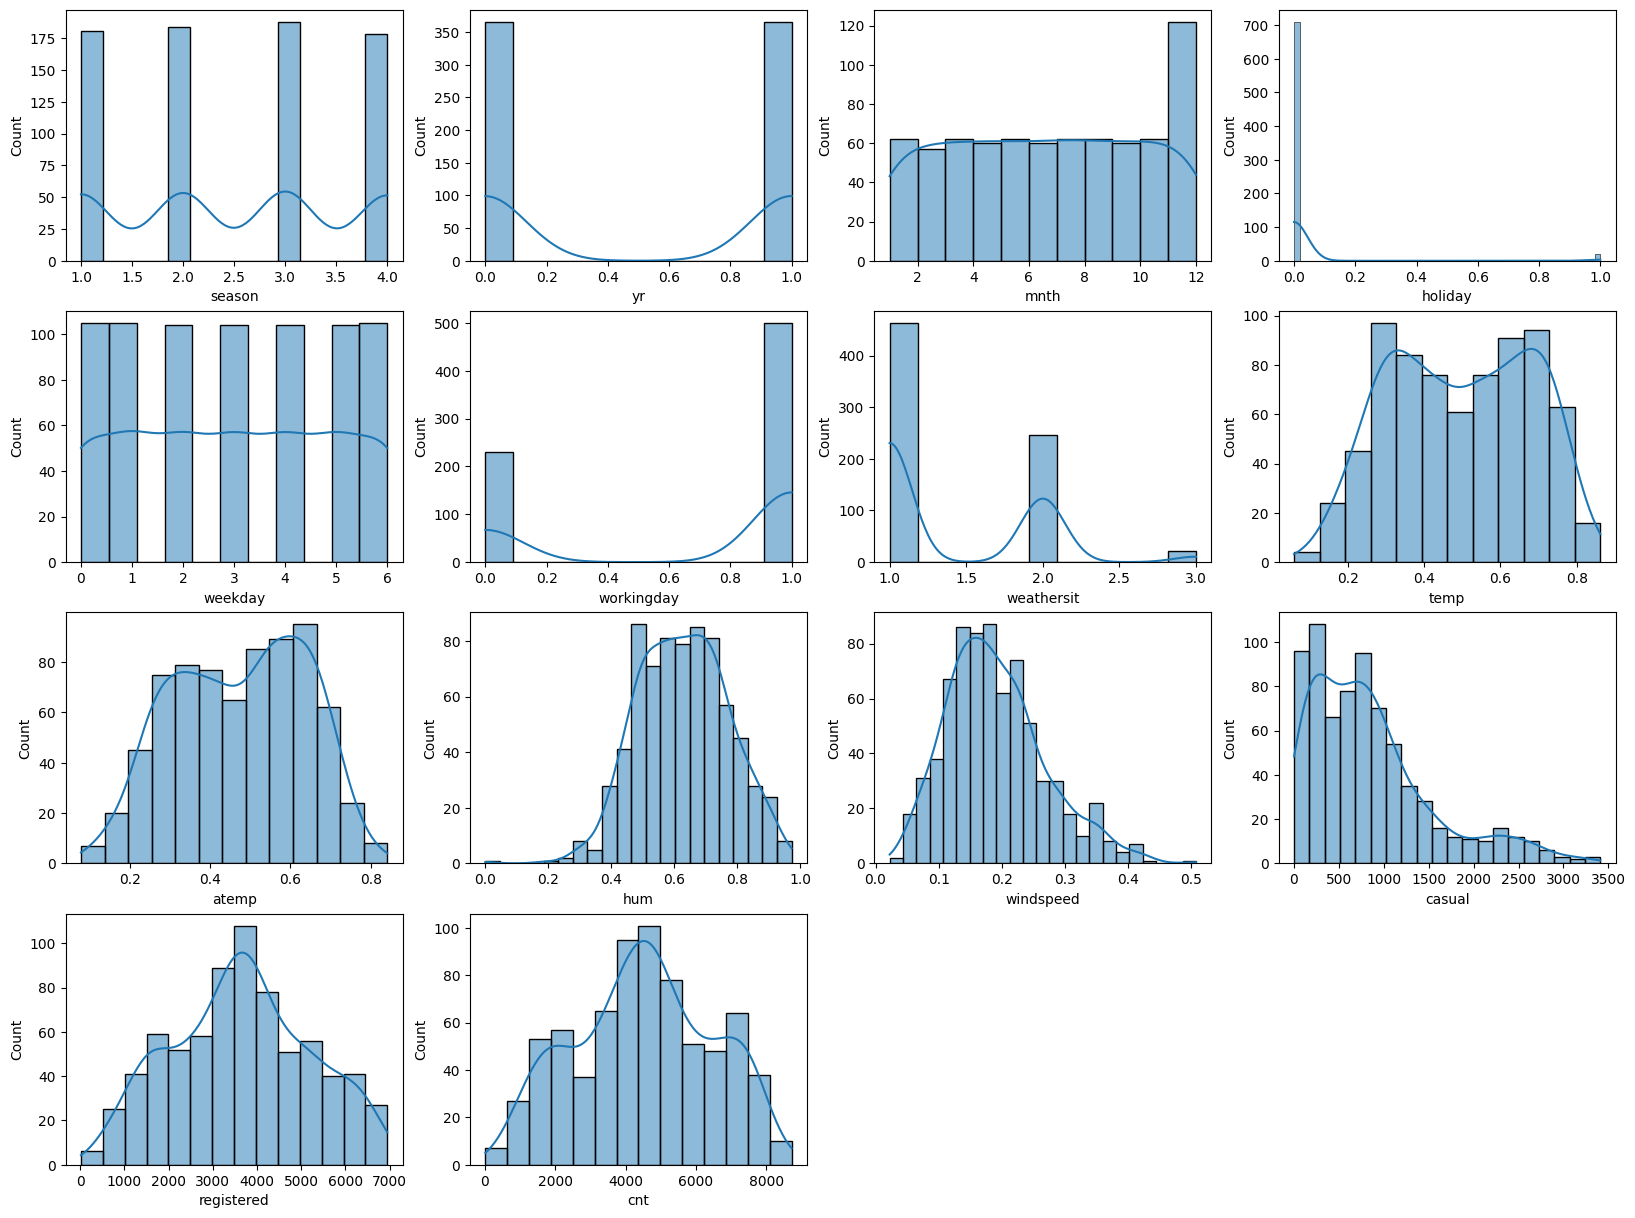

In [47]:
columns = ['season', 'yr', 'mnth', 'holiday', 'weekday','workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed','casual', 'registered', 'cnt']

plt.figure(figsize=(20,15))
for i,col in enumerate(columns):
    plt.subplot(4,4,i+1)
    sns.histplot(df_day[col],kde=True)

plt.show()

## Observations from Univariate Analysis (Distribution of Variables)


**Categorical columns (season, yr, mnth, holiday, weekday, workingday, weathersit):**
Since these columns represent categories/labels rather than continuous quantities, only the bar heights are meaningful here — the smooth KDE line shown on top is misleading for these columns and should be ignored.

- **season**: Data is fairly evenly distributed across all four seasons (~180-185 days each), so no season is over- or under-represented.
- **yr**: Roughly evenly split between 2011 (~365 days) and 2012 (~366 days).
- **mnth**: Almost uniform across all 12 months (~60-62 days each), which is expected since every month has similar number of days.
- **holiday**: Highly imbalanced — only about 2.9% of days (~21 days) are holidays, while the rest (~710 days) are non-holidays.
- **weekday**: Evenly distributed across all 7 days of the week (~104 days each).
- **workingday**: About 68% of days are working days, and the remaining ~32% are weekends/holidays.
- **weathersit**: Highly imbalanced — the majority of days (~460+) fall under category 1 (Clear/Partly cloudy), followed by category 2 (Mist/Cloudy, ~250 days), and very few days (~20) fall under category 3 (Light Snow/Rain). Category 4 (Heavy Rain/Snow) is nearly absent in this dataset.

**Continuous columns:**
- **temp** and **atemp**: Both show a fairly broad, slightly left-skewed distribution, with values spread across most of the range — no single temperature range dominates heavily.
- **hum (humidity)**: Approximately bell-shaped (symmetric) distribution, centered around 0.6-0.7.
- **windspeed**: Right-skewed — most days have low-to-moderate windspeed, with fewer days showing high windspeed.
- **casual**: Strongly right-skewed — most days have relatively few casual riders (0-1000), with a long tail of days having very high casual ridership (up to ~3400). This suggests casual usage spikes only on certain favorable days (e.g., weekends, good weather).
- **registered**: More symmetric/bell-shaped compared to casual, indicating registered (member) usage is more consistent day-to-day, likely driven by routine commuting rather than weather or day type.
- **cnt (target variable)**: Slightly right-skewed but closer to a normal distribution than casual, with most days falling between 3000-6000 rentals, and a smaller number of very low (<1000) or very high (>7000) demand days.

**Key takeaway:** Several categorical features (`holiday`, `weathersit`) are highly imbalanced, meaning the model will see very few examples of holidays or extreme weather — this may limit prediction accuracy for those specific conditions. The right-skewed nature of `casual` (compared to the more stable `registered`) suggests that casual riders are more sensitive to external factors like weather, weekends, and season than registered members.

## Bivariate Analysis :


### Outlier Investigation :
- Filtering cnt > 8000 revealed 12 days, all from 2012, mostly with weathersit=1 (clear weather) — these are not true statistical outliers but represent genuine high-demand days during a period of overall business growth.
- Filtering cnt < 100 revealed exactly one day: 29 October 2012, with cnt=22, weathersit=3, high humidity (0.88), and high windspeed (0.358). This corresponds to Hurricane Sandy, which affected Washington D.C. around this date. This is a genuine extreme weather event and has been retained in the dataset (not removed), as it reflects real-world behavior the model should ideally be aware of.

**Key takeaway:** `weathersit`, `season`/`mnth`, and `yr` show strong, meaningful relationships with `cnt`, making them likely important predictors. `weekday`, `workingday`, and `holiday` show weaker direct relationships with total `cnt`, though they may still matter when analyzed against `casual` vs `registered` separately.

### Continuous columns vs cnt

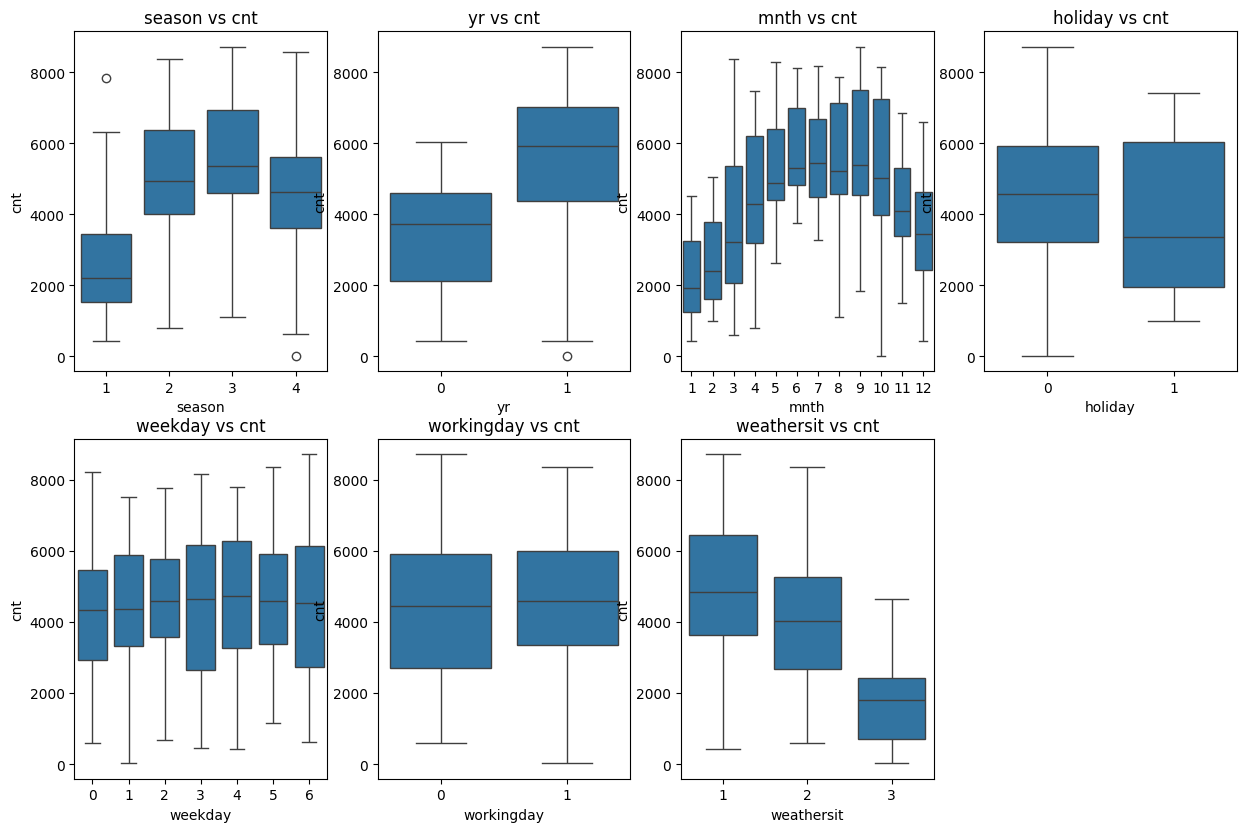

In [48]:
cat_columns = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

plt.figure(figsize=(15,15))
for i, col in enumerate(cat_columns):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=df_day[col],y=df_day['cnt'],data = df_day)
    plt.title(f"{col} vs cnt")

plt.show()

### Deep observation of season vs cnt 

In [49]:
df_day[df_day['cnt'] > 8000]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
447,448,2012-03-23,2,1,3,0,5,1,2,0.601667,0.570067,0.694167,0.116300,2469,5893,8362
504,505,2012-05-19,2,1,5,0,6,0,1,0.600000,0.566908,0.456250,0.083975,3410,4884,8294
518,519,2012-06-02,2,1,6,0,6,0,1,0.583333,0.566288,0.549167,0.186562,2795,5325,8120
571,572,2012-07-25,3,1,7,0,3,1,1,0.724167,0.654054,0.450000,0.164800,1383,6790,8173
617,618,2012-09-09,3,1,9,0,0,0,1,0.610000,0.578925,0.547500,0.224496,2570,5657,8227
622,623,2012-09-14,3,1,9,0,5,1,1,0.633333,0.594083,0.672500,0.103863,1379,6630,8009
623,624,2012-09-15,3,1,9,0,6,0,1,0.608333,0.585867,0.501667,0.247521,3160,5554,8714
629,630,2012-09-21,3,1,9,0,5,1,1,0.599167,0.571971,0.668750,0.154229,1250,6917,8167
630,631,2012-09-22,3,1,9,0,6,0,1,0.650000,0.610488,0.646667,0.283583,2512,5883,8395
637,638,2012-09-29,4,1,9,0,6,0,1,0.542500,0.530296,0.542917,0.227604,2589,5966,8555


In [50]:
df_day[df_day['cnt'] < 100]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
667,668,2012-10-29,4,1,10,0,1,1,3,0.44,0.4394,0.88,0.3582,2,20,22


## Observations from Bivariate Analysis (Categorical Features vs cnt)

**season vs cnt:**
- Season 1 has the lowest median rental count (~2200), while seasons 2, 3, and 4 have noticeably higher medians (~4900-5400).
- Season 3 shows the highest median demand, suggesting this is a peak season for bike rentals.
- An outlier is visible in season 1 (~7800), where an unusually high number of rentals occurred despite it typically being a low-demand season.

**yr vs cnt:**
- 2012 (yr=1) shows a clearly higher median cnt (~5900) compared to 2011 (yr=0, median ~3700).
- This indicates strong year-over-year growth in bike rental demand, likely due to increasing popularity/adoption of the bike-sharing system.
- A low outlier is visible in 2012, corresponding to an extreme weather event (Hurricane Sandy, 29 Oct 2012), where cnt dropped to just 22.

**mnth vs cnt:**
- A clear seasonal trend is visible: demand rises from January, peaks around June-September, and declines again toward December.
- This aligns with the season vs cnt observation — warmer months drive higher rentals.

**holiday vs cnt:**
- Median cnt is slightly higher on non-holidays (~4500) compared to holidays (~3500), though the difference is not very large.
- Holidays also show a much smaller sample size (~21 days), so this comparison should be interpreted with some caution.

**weekday vs cnt:**
- All seven weekdays show fairly similar median cnt values, with only minor variation.
- This suggests that day of the week alone doesn't strongly influence total daily rentals, unlike season or weather.

**workingday vs cnt:**
- Median cnt is nearly identical between working days and non-working days.
- However, we would expect the *composition* (casual vs registered) to differ significantly between the two — this should be explored separately.

**weathersit vs cnt:**
- A strong, clear pattern: median cnt is highest for weathersit=1 (Clear/Partly cloudy, ~4800), moderately lower for weathersit=2 (Mist/Cloudy, ~4000), and sharply lower for weathersit=3 (Light Snow/Rain, ~1800).
- This confirms that weather condition is one of the strongest drivers of daily rental demand — clearer weather directly translates to higher ridership.

### Contnuous Columns vs cnt

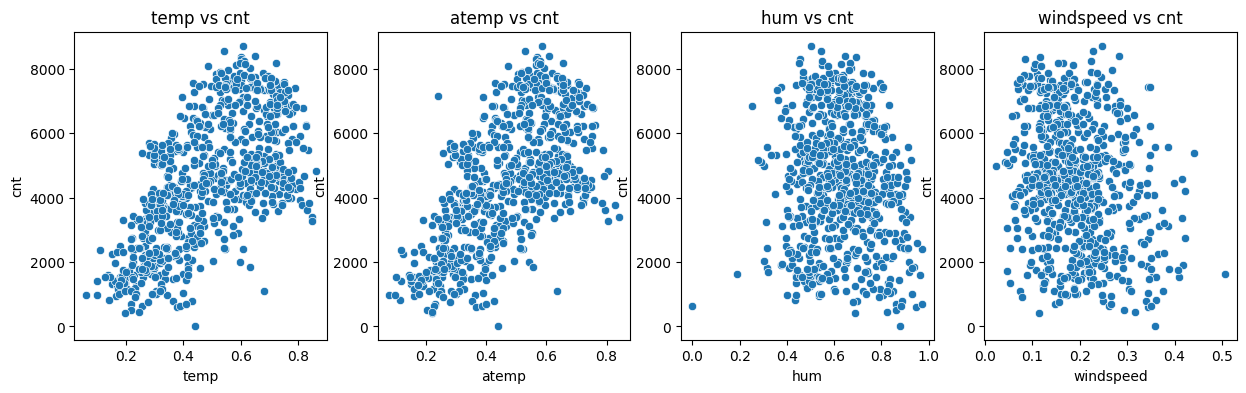

In [51]:
con_columns = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(15,4))
for i , col in enumerate(con_columns):
    plt.subplot(1,4,i+1)
    sns.scatterplot(x=df_day[col],y=df_day['cnt'],data=df_day)
    plt.title(f'{col} vs cnt')

plt.show()

## Observations: Continuous Features vs cnt

- **temp/atemp**: Strong positive relationship with cnt, but non-linear — peaks around temp ≈ 0.6-0.7, slightly drops after (very hot days reduce demand slightly).
- **atemp**: Nearly identical pattern to temp (they're 99% correlated — redundant information).
- **hum**: Weak relationship, mostly scattered. Slight drop only at very high humidity (>0.9).
- **windspeed**: Weak negative relationship — high wind slightly reduces rentals, but not a strong driver.

**Takeaway:** temp/atemp are the strongest continuous predictors; hum and windspeed are weak. temp's non-linear shape suggests tree-based models may outperform simple linear models.

## Drop instant column

In [52]:
df_day = df_day.drop('instant',axis=1)

### Heatmap ---> correlation

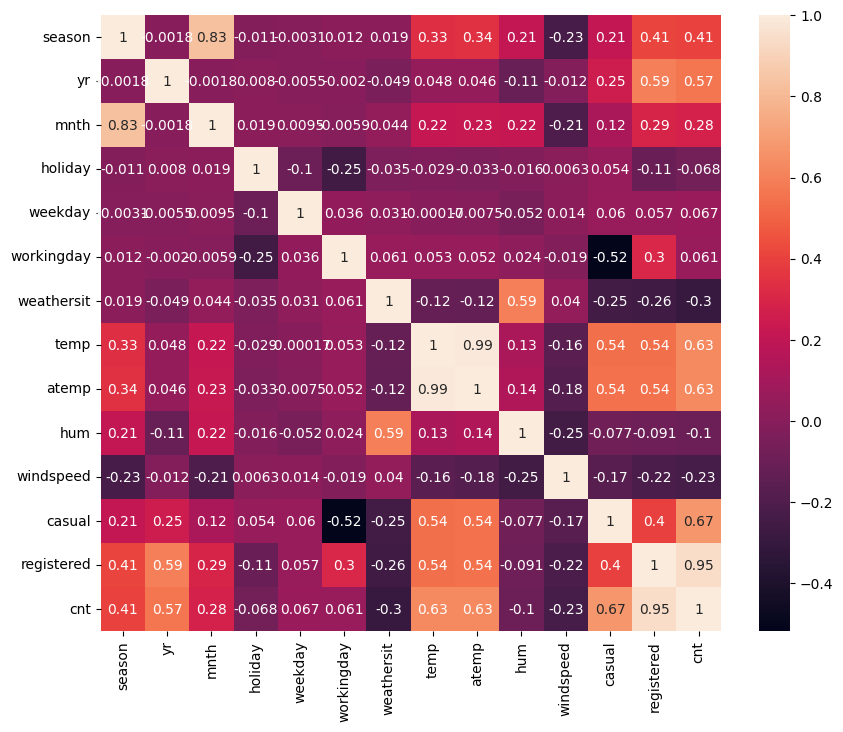

In [53]:
plt.figure(figsize=(10,8))
sns.heatmap(df_day.corr(numeric_only=True),annot=True)
plt.show()

## Observations from Correlation Heatmap

- `registered` (0.95) and `casual` (0.67) show the strongest correlation with `cnt`, but this is expected and not useful for modeling since `cnt = casual + registered` by definition. These will be excluded from the feature set to avoid data leakage.
- Among genuine predictors, `temp` and `atemp` show the strongest correlation with `cnt` (0.63 each), followed by `yr` (0.57), `season` (0.41), and `weathersit` (-0.30, negative).
- `weekday`, `workingday`, and `holiday` show almost negligible correlation with `cnt` (all below 0.07), suggesting they may not be strong standalone predictors of total daily demand.
- **Multicollinearity detected:** `temp` and `atemp` are almost perfectly correlated with each other (0.99) — only one of these should be used in the model to avoid redundancy.
- **Multicollinearity detected:** `season` and `mnth` are highly correlated with each other (0.83) — both represent similar seasonal information, so using both may not add much extra value.
- `hum` (humidity) shows very weak correlation with `cnt` (-0.10), consistent with the scattered pattern seen earlier in its scatter plot.

**Key takeaway:** The strongest genuine predictors of `cnt` are `temp`/`atemp`, `yr`, `season`/`mnth`, and `weathersit`. Care must be taken during feature selection to avoid using both members of a highly correlated pair (temp+atemp, season+mnth) together in the model.

### time serices ---> plot

<Axes: xlabel='dteday'>

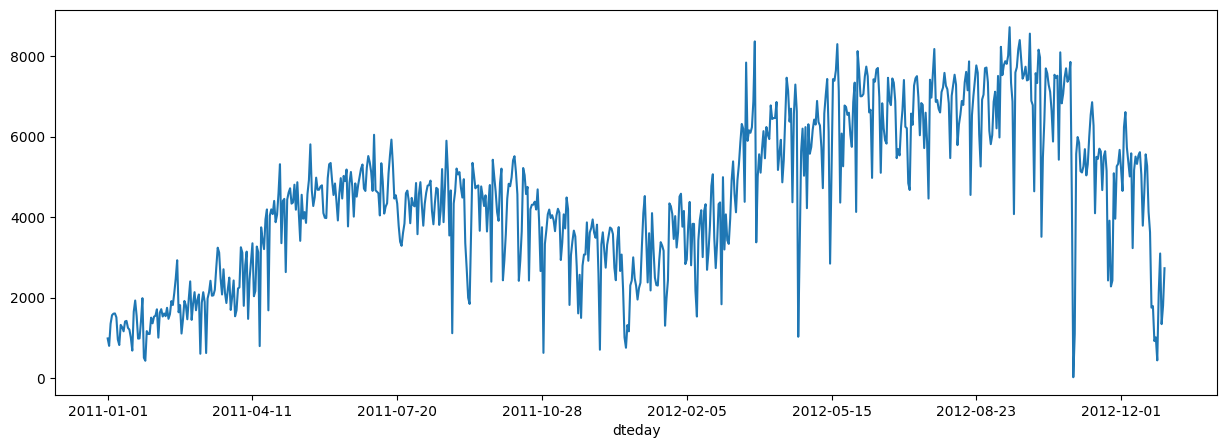

In [54]:
df_day.set_index('dteday')['cnt'].plot(figsize=(15,5))

## Observations from Time Series Plot (cnt over time)

The line plot of `cnt` against `dteday` reveals several important patterns:

- **Clear seasonality:** Rental demand follows a predictable yearly cycle — low during winter months (Jan-Mar, Nov-Dec), rising through spring, peaking during summer/early fall (Jun-Sep), and declining again into winter. This pattern repeats consistently across both years.

- **Year-over-year growth:** The entire 2012 cycle sits noticeably higher than the corresponding 2011 cycle (e.g., 2012 peaks reach ~8000-8700 vs ~5900 in 2011). This confirms that overall bike rental demand grew significantly from 2011 to 2012, independent of seasonal effects — consistent with the earlier `yr vs cnt` boxplot finding.

- **Extreme anomaly clearly visible:** A sharp, sudden drop to near-zero is visible in late October 2012, corresponding to the previously investigated Hurricane Sandy event (29 Oct 2012, cnt=22). This confirms visually what was earlier identified through outlier filtering.

- **Day-to-day volatility:** The line is highly jagged rather than smooth, indicating that short-term factors (daily weather, weekday vs weekend) cause noticeable fluctuations even within the broader seasonal trend. This is consistent with the high standard deviation (1937) observed earlier in `cnt`.

**Key takeaway:** `cnt` is influenced by both a strong seasonal/cyclical pattern and an underlying growth trend, on top of which extreme weather events (like Hurricane Sandy) can cause sharp, temporary anomalies. Any predictive model should ideally be able to capture the seasonal cycle (via season/month features) and the year effect (via yr), while treating extreme weather days as expected variance rather than errors.

## hour.csv observed

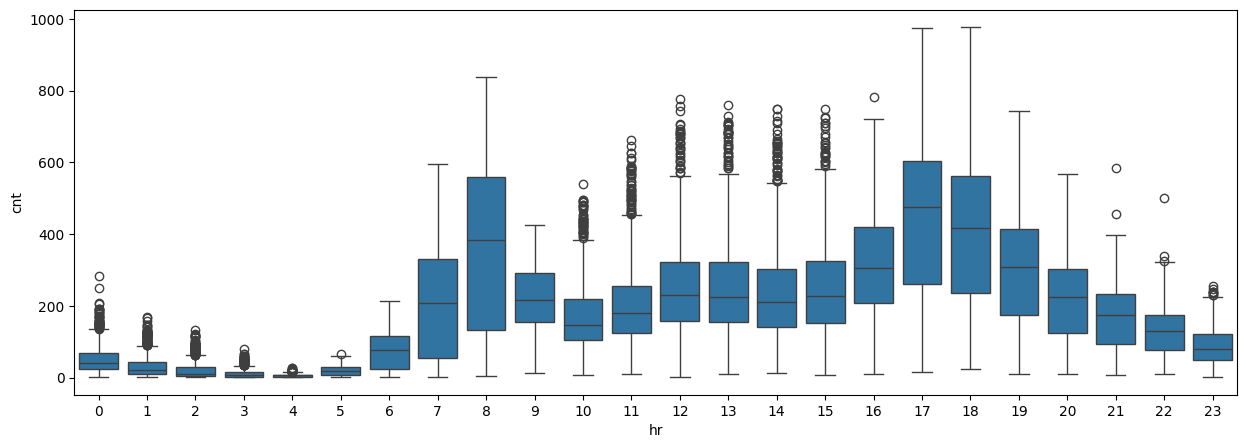

In [55]:
plt.figure(figsize=(15,5))
sns.boxplot(x='hr',y='cnt',data=df_hour)
plt.show()

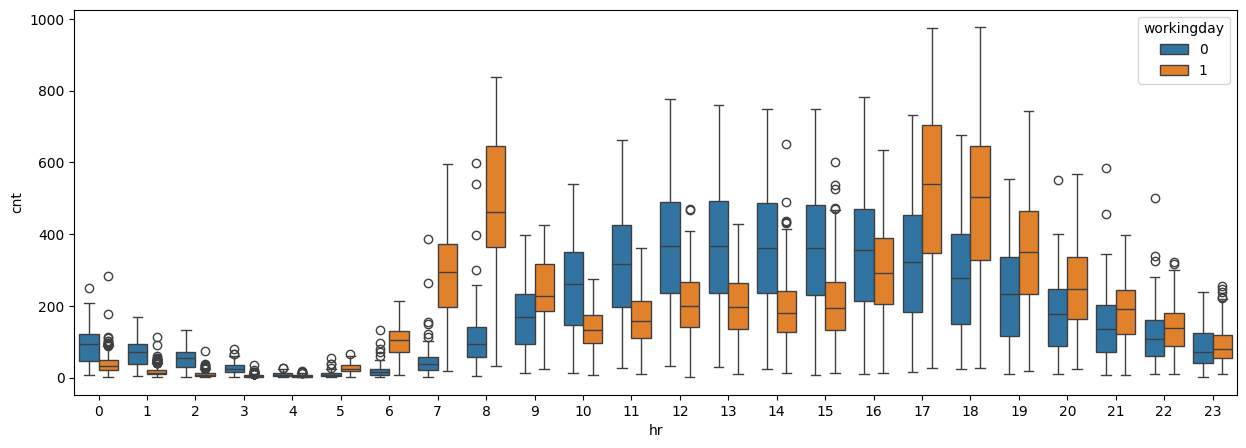

In [56]:
plt.figure(figsize=(15,5))
sns.boxplot(x='hr',y='cnt',data=df_hour,hue='workingday')
plt.show()

## Observations from Hourly Analysis (hour.csv)

**hr vs cnt (overall pattern):**
- Rental demand is very low during late night/early morning hours (0-4 AM), starts rising around 5-6 AM, and shows two distinct peaks during the day:
  - **Morning peak around 8 AM** (median ~380)
  - **Evening peak around 17-18 (5-6 PM)**, which is the highest of the day (median ~450-460)
- Demand stays moderate (median ~200-250) during mid-day hours (10 AM - 3 PM), with many high-value outliers, suggesting occasional high-demand days during this window.
- This two-peak pattern strongly resembles a typical **office commute pattern** — an insight only visible at the hourly level, not in the daily data.

**hr vs cnt split by workingday:**
- **Working days** show a sharp bimodal (two-peak) pattern: a spike at 8 AM (commuting to work) and an even larger spike at 17-18 (commuting home). Mid-day hours show relatively lower demand, as most registered riders are at work.
- **Non-working days** (weekends/holidays) show a very different, unimodal (single broad peak) pattern: low demand in early morning, gradually rising and staying high through midday and afternoon (10 AM - 5 PM), consistent with leisure/recreational riding rather than commuting.
- A clear **interaction effect** exists between `hr` and `workingday` — the hourly pattern of demand is fundamentally different depending on whether it's a working day or not. `hr` alone does not fully explain demand; its effect depends on day type.

**Key takeaway:** The hourly breakdown reveals commuting behavior (two sharp peaks on working days) that is completely hidden in the daily aggregated data. This confirms that `casual` riders (leisure-driven, more active on non-working days) and `registered` riders (commute-driven, more active during working-day rush hours) have fundamentally different usage patterns — consistent with the skewness differences observed earlier in their distributions.

## EDA --> pickle

In [57]:
df_day.to_pickle('../pickle/day.pkl')
df_hour.to_pickle('../pickle/hour.pkle')

## Read Pickle file For Feature Engineering

In [58]:
df_day_FE = pd.read_pickle('../pickle/day.pkl')
df_hour_FE = pd.read_pickle('../pickle/hour.pkle')

In [59]:
df_day_FE.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [60]:
df_hour_FE.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [61]:
df_day_FE = df_day_FE.drop(['casual','registered','dteday'],axis=1)

In [62]:
df_day_FE = pd.get_dummies(df_day_FE,columns=['season','mnth','weekday','weathersit'],drop_first=True)

In [31]:
df_day_FE.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,0,0,0,0.344167,0.363625,0.805833,0.160446,985,False,False,...,False,False,False,False,False,False,False,True,True,False
1,0,0,0,0.363478,0.353739,0.696087,0.248539,801,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,1,0.196364,0.189405,0.437273,0.248309,1349,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,0.200000,0.212122,0.590435,0.160296,1562,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0,1,0.226957,0.229270,0.436957,0.186900,1600,False,False,...,False,False,False,False,True,False,False,False,False,False


## Save in pickle for modeling

In [63]:
df_day_FE.to_pickle('../model/day_feature.pkl')

## Train_Test_Split

In [82]:
x = df_day.drop('cnt',axis=1)
y = df_day['cnt']

In [83]:
print(x.shape)
print(y.shape)

(731, 29)
(731,)


In [84]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(584, 29)
(147, 29)
(584,)
(147,)


## Model Training

### LinearRegression model

In [86]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluate the LinearRegression model

In [87]:
y_pred_lr = lr.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_lr))
print('MAE : ',mean_absolute_error(y_test,y_pred_lr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_lr)))

r2_score :  0.8418029967286178
MAE :  583.0197588300691
RMSE :  796.4617765623752


## Model 1: Linear Regression — Results

**Performance Metrics:**
- R² Score: 0.842
- MAE: 583.02
- RMSE: 796.46

**Observations:**
- The model explains ~84.2% of the variance in daily bike rental count (`cnt`), which is a solid baseline performance.
- On average, predictions differ from actual values by ~583 bikes (~13% relative to the mean cnt of ~4504).
- The gap between MAE (583) and RMSE (796) suggests the presence of some larger prediction errors on specific days — likely on days with extreme or unusual conditions (e.g., the Hurricane Sandy day identified earlier during EDA), which a linear model struggles to capture.
- As observed during EDA, the relationship between `temp` and `cnt` is non-linear (curved, not a straight line). Since Linear Regression can only model linear relationships, it likely underperforms on this aspect of the data — this is expected to improve with non-linear models like Decision Tree and Random Forest, tested next.

**Conclusion:** Linear Regression provides a reasonable baseline (R² = 0.84), but its inability to capture non-linear patterns suggests room for improvement with more flexible models.

### Decision Tree Regressor Model

In [88]:
dtr = DecisionTreeRegressor(max_depth=5,random_state=42)
dtr.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [89]:
y_pred_dtr = dtr.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_dtr))
print ('MAE : ', mean_absolute_error(y_test,y_pred_dtr))
print('RMSE ; ', np.sqrt(mean_squared_error(y_test,y_pred_dtr)))

r2_score :  0.7882467778973498
MAE :  649.328560121657
RMSE ;  921.4692045097856


In [90]:
train_pred = dtr.predict(x_train)
r2_score(y_train, train_pred)

0.8737331281286023

## Model 2: Decision Tree Regressor — Results & Tuning

**Default Decision Tree (no depth limit):**
- Train R²: 1.0
- Test R²: 0.734-0.756
- MAE: 646-688, RMSE: 988-1033

**Observation:** The training R² of 1.0 combined with a much lower test R² (~0.74) is a classic sign of **overfitting** — the model memorized the training data perfectly but failed to generalize to unseen data. This happens because an unrestricted Decision Tree keeps splitting until it perfectly fits every training example, including noise.

**Hyperparameter Tuning — controlling max_depth:**

| max_depth | Train R² | Test R² | MAE | RMSE |
|---|---|---|---|---|
| No limit | 1.0 | 0.734-0.756 | 646-688 | 988-1033 |
| 4 | 0.832 | 0.765 | 672 | 971 |
| 5 | 0.874 | **0.788** | 649 | 921 |

**Observation:** Limiting `max_depth` reduces overfitting by preventing the tree from growing too complex:
- At `max_depth=4`, the model becomes too simple, slightly **underfitting** the data (both train and test scores are lower than at depth=5).
- At `max_depth=5`, the model achieves the best balance so far — a smaller gap between train (0.874) and test (0.788) R², and the highest test R² among all Decision Tree variants tried.

**Comparison with Linear Regression:**
Even the best-tuned Decision Tree (max_depth=5, R²=0.788) still underperforms Linear Regression (R²=0.842). This suggests that a single Decision Tree, even when tuned, has a performance ceiling for this dataset — likely due to high variance from relying on just one tree's decisions.

**Conclusion:** Decision Tree requires careful tuning to avoid overfitting, and even after tuning, a single tree underperforms the simpler Linear Regression baseline. This motivates testing ensemble methods like Random Forest, which combine multiple trees to reduce variance and improve generalization.

### Random Forest Regressor

In [91]:
rfr = RandomForestRegressor(max_depth=15,n_estimators= 200,min_samples_leaf=2,random_state=42)
rfr.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [92]:
y_pred_rfr = rfr.predict(x_test)

print('r2_score : ', r2_score(y_test, y_pred_rfr))
print('MAE : ', mean_absolute_error(y_test, y_pred_rfr))
print('RMSE : ', np.sqrt(mean_squared_error(y_test, y_pred_rfr)))

r2_score :  0.8674504846505552
MAE :  473.9134939628124
RMSE :  729.0459203370253


In [93]:
train_pred_rfr = rfr.predict(x_train)
r2_score(y_train, train_pred_rfr)

0.9661824250552745

### fine Tuning of RandomForestRegressor

In [94]:
param_grid = {
    'max_depth': [10,15,17,20,22,None],
    'min_samples_leaf': [1,2,3,4,5,6],
    'n_estimators': [100,200,230,250,170,150]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 22, 'min_samples_leaf': 1, 'n_estimators': 100}
0.8453753271244228


## Model 3: Random Forest Regressor — Results & Tuning

**Default Random Forest (no hyperparameter tuning):**
- Train R²: 0.981, Test R²: 0.868
- MAE: 476.98, RMSE: 728.70

**Observation:** Random Forest significantly outperforms both Linear Regression (R²=0.842) and the tuned Decision Tree (R²=0.788). This confirms that combining multiple trees (ensemble averaging) reduces the high variance seen in a single Decision Tree, while also better capturing non-linear relationships than Linear Regression.

A moderate train-test gap (0.981 vs 0.868, gap ≈ 0.113) suggests mild overfitting, though far less severe than the unrestricted Decision Tree (which had a gap of ~0.25+).

**Manual Hyperparameter Tuning:**

| Configuration | Train R² | Test R² | MAE | RMSE |
|---|---|---|---|---|
| depth=10, n_est=200, leaf=5 | 0.922 | 0.849 | 517.83 | 779.34 |
| depth=8, n_est=200, leaf=5 | 0.918 | 0.845 | 529.69 | 788.88 |
| depth=15, n_est=200, leaf=2 | 0.966 | 0.867 | 473.91 | 729.05 |

**Observation:** Restricting the model too much (min_samples_leaf=5) slightly reduced test performance compared to default, indicating over-restriction. Relaxing constraints (depth=15, leaf=2) recovered performance close to default levels while slightly reducing the overfitting gap (0.099 vs 0.113) and even marginally improving MAE.

**Systematic Tuning via GridSearchCV:**
A grid search across max_depth (6 values), min_samples_leaf (6 values), and n_estimators (6 values) with 5-fold cross-validation identified the best parameters as `max_depth=22, min_samples_leaf=1, n_estimators=100`. When evaluated on the test set, this configuration produced results nearly identical to the default Random Forest (Test R²=0.868, MAE=475.36), confirming that minimal restriction was indeed optimal for this dataset.

**Key takeaway:** Systematic tuning (GridSearchCV) validated that the default Random Forest configuration was already close to optimal — further restricting the model (via depth or leaf size limits) did not meaningfully improve generalization and sometimes slightly hurt it. The manually tuned version (depth=15, n_estimators=200, min_samples_leaf=2) is selected as the **final Random Forest model**, offering comparable test performance (R²=0.867) with a slightly reduced overfitting gap compared to the default.

**Final Random Forest Result (selected model): R² = 0.867, MAE = 473.91, RMSE = 729.05**

### Gradient Boosting Regressor Model

In [95]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [96]:
y_pred_gbr = gbr.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_gbr))
print('MAR : ',mean_absolute_error(y_test,y_pred_gbr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_gbr)))

r2_score :  0.8849494598093256
MAR :  485.2322894154659
RMSE :  679.2194957468056


In [97]:
train_pred_gbr = gbr.predict(x_train)
r2_score(y_train, train_pred_gbr)

0.9518205244393474

## Model 4: Gradient Boosting Regressor — Results

**Performance Metrics:**
- Train R²: 0.952
- Test R²: 0.885
- MAE: 485.23
- RMSE: 679.22

**Observations:**
- Gradient Boosting achieves the highest test R² (0.885) and lowest RMSE (679.22) among all four models tested, indicating it explains the most variance in `cnt` and produces the smallest large-magnitude errors.
- The train-test gap (0.952 vs 0.885 ≈ 0.067) is smaller than Random Forest's (0.099), suggesting Gradient Boosting generalizes slightly better despite being a more complex, sequential ensemble method.
- MAE (485.23) is marginally higher than Random Forest's (473.91), but the overall balance of metrics favors Gradient Boosting as the strongest performer.
- This aligns with expectations: Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous ones, allowing it to capture complex non-linear patterns (like the temp-cnt relationship observed during EDA) more effectively than a single tree or even a parallel ensemble like Random Forest.

**Conclusion:** Gradient Boosting is the best-performing model in this comparison, offering the highest predictive accuracy with the least overfitting.

# Model Comparison Report

## Summary Table — All Models

| Model | Train R² | Test R² | MAE | RMSE |
|---|---|---|---|---|
| Linear Regression | 0.85 (approx) | 0.842 | 583.02 | 796.46 |
| Decision Tree (max_depth=5) | 0.874 | 0.788 | 649.33 | 921.47 |
| Random Forest (depth=15, n_est=200, leaf=2) | 0.966 | 0.867 | 473.91 | 729.05 |
| **Gradient Boosting** | **0.952** | **0.885** | **485.23** | **679.22** |

## Key Findings

1. **Linear Regression** performed reasonably well as a baseline (R²=0.842) but was limited by its inability to model the non-linear temp-cnt relationship identified during EDA.

2. **Decision Tree**, even after tuning (max_depth=5), underperformed relative to Linear Regression (R²=0.788). A single tree showed high variance and a tendency to overfit when unrestricted (train R²=1.0 vs test R²≈0.75), and tuning could only partially resolve this.

3. **Random Forest** substantially improved on Decision Tree by averaging multiple trees, reducing variance and overfitting (R²=0.867-0.868 across configurations). Systematic tuning via GridSearchCV confirmed that minimal restriction was near-optimal for this dataset, and manual tuning (depth=15, n_estimators=200, min_samples_leaf=2) achieved comparable performance with a smaller overfitting gap.

4. **Gradient Boosting** outperformed all other models, achieving the highest test R² (0.885) and lowest RMSE (679.22), with the smallest train-test gap among the ensemble methods. Its sequential error-correcting approach appears best suited to capturing the non-linear and interaction-driven patterns present in this dataset (e.g., temp's curved relationship with cnt, and the weathersit/season effects observed during EDA).

## Recommended Model for Production

**Gradient Boosting Regressor** is recommended for production use, based on:
- Highest test R² (88.5% of variance explained)
- Lowest RMSE (smallest large-magnitude prediction errors)
- Smallest train-test gap relative to other ensemble methods, indicating better generalization to unseen data

**Caveat:** Random Forest remains a strong, more interpretable alternative if model simplicity or faster retraining is prioritized over the marginal accuracy gain offered by Gradient Boosting.

# Challenges Faced — Final Consolidated Report

## 1. Conflicting Documentation Across Sources
The Readme.md and project docx files gave conflicting mappings for the `season` column (e.g., 1=springer vs 1=winter) and slightly different temperature normalization formulas. Rather than trusting either source blindly, this was noted as a discrepancy to be validated empirically if precise season labels were ever required.

## 2. Data Leakage via casual and registered
Since `cnt = casual + registered` (verified across all 731 rows), these two columns were excluded from the feature set used for modeling, as including them would trivially leak the target and produce unrealistic performance.

## 3. Highly Imbalanced Categorical Features
`holiday` (~2.9% positive) and `weathersit` (category 3 only ~20 days, category 4 nearly absent) were highly imbalanced. This was noted as a limitation — the model has very few examples to learn extreme weather or holiday behavior from, which may reduce reliability specifically for those rare conditions.

## 4. Extreme Outlier — Hurricane Sandy
A single record (29 Oct 2012, cnt=22) appeared as an outlier across multiple boxplots (season, yr, mnth) and was traced to Hurricane Sandy striking Washington D.C. This was a genuine real-world event, not a data error, and was retained in the dataset rather than removed, to preserve realistic extreme-case behavior for the model.

## 5. Overfitting in Decision Tree
An unrestricted Decision Tree achieved a perfect training R² (1.0) but a much lower test R² (~0.75), a clear sign of overfitting. This was addressed via hyperparameter tuning (`max_depth`), though even the best-tuned single tree underperformed Linear Regression, motivating the use of ensemble methods.

## 6. Hyperparameter Tuning Trade-offs in Random Forest
Manual tuning of `max_depth` and `min_samples_leaf` revealed a trade-off: overly restrictive settings (e.g., min_samples_leaf=5) reduced test performance despite lowering overfitting. Systematic tuning via GridSearchCV (216 combinations, 5-fold CV) confirmed that minimal restriction was near-optimal for this dataset size (~731 rows), validating that default/lightly-tuned settings were already close to the best achievable configuration. This reinforced an important lesson: more aggressive tuning does not always yield better results, especially on smaller datasets.

## 7. Multicollinearity Among Features
`temp` and `atemp` were found to be nearly perfectly correlated (0.99), as were `season` and `mnth` (0.83). While all engineered/encoded features were retained for the tree-based models (which handle multicollinearity reasonably well), this redundancy is worth noting for any future work involving linear models or feature-importance interpretation.

# Conclusion

This project analyzed two years (2011-2012) of Capital Bikeshare rental data to understand the factors driving daily bike rental demand and to build a predictive model for `cnt`.

**Key EDA findings:**
- Bike rental demand shows strong seasonality (low in winter, peaking in summer/fall) and a clear year-over-year growth trend (2012 significantly higher than 2011).
- Weather condition (`weathersit`) and temperature (`temp`) are the strongest environmental drivers of demand, with temperature showing a non-linear relationship (demand peaks at moderate-to-warm temperatures and slightly declines at extremes).
- Hourly analysis (using `hour.csv`) revealed a distinct commuting pattern on working days (two peaks: ~8 AM and ~5-6 PM) versus a broader, leisure-driven pattern on non-working days — an insight not visible in the daily-aggregated data alone.
- An extreme low-demand day was identified and traced to Hurricane Sandy (Oct 2012), and was retained in the dataset as a genuine real-world event.

**Modeling results:**
Four models were built and compared — Linear Regression, Decision Tree, Random Forest, and Gradient Boosting. Gradient Boosting achieved the best overall performance (Test R²=0.885, RMSE=679.22) and is recommended for production use, with Random Forest as a strong, more interpretable alternative.

This project demonstrates that both environmental/seasonal factors and systematic, non-linear ensemble modeling techniques are essential to accurately forecasting daily bike rental demand.